In [1]:
import os

# Define a local folder to save everything persistently for this session
# Renamed for the 128x128 input-resolution run -- old 64x64 checkpoints are
# shape-incompatible with this run and must not be loaded into it.
SAVE_DIR = 'EuroSAT_Models_128'
os.makedirs(SAVE_DIR, exist_ok=True)


# Land-Cover Classification with EuroSAT - ResNet152V2 (v3.3 - Auto-Resume)

This notebook trains and evaluates a **ResNet152V2** model on the EuroSAT RGB
dataset for land-cover classification (10 classes, 64x64 satellite patches).

It is one model in a larger comparison study (ResNet50, ResNet50V2,
ResNet152V2, VGG16, VGG19, etc.). Each model lives in its own self-contained
notebook so it can be run and graded independently; this one covers
**ResNet152V2 only**.

**Pipeline:**
1. Download the dataset (via `kagglehub`)
2. Split into train/test sets and set up data generators
3. Build a ResNet152V2-based classifier (ImageNet weights + custom head)
4. Train in two stages - frozen backbone, then full fine-tuning
5. Evaluate on the test set and save the trained model

**v2 improvements:** This version automatically saves progress after
every epoch and resumes from the last checkpoint if the Kaggle session
crashes or disconnects. Just re-run all cells - no manual changes needed.

**Reference:** Helber et al., *EuroSAT: A Novel Dataset and Deep Learning
Benchmark for Land Use and Land Cover Classification*, IEEE JSTARS, 2019.

## 1. Setup

Import the libraries used throughout this notebook.

In [2]:
import os
import re
import shutil

from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    precision_recall_fscore_support,
    confusion_matrix,
    f1_score,
    fbeta_score,
    accuracy_score,
)

import tensorflow as tf
from keras.models import Model
from keras.layers import Dense, Dropout, GlobalAveragePooling2D
from keras.regularizers import l2
from keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger
from keras.optimizers import Adam
from keras.optimizers.schedules import CosineDecayRestarts
from keras.applications import ResNet152V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2026-06-26 02:07:19.180521: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782439639.400486      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782439639.459187      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782439639.976114      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782439639.976151      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782439639.976154      23 computation_placer.cc:177] computation placer alr

**GPU configuration.** If a GPU is available, restrict TensorFlow to the
first one and enable soft device placement so ops fall back to CPU when
needed.

In [3]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_visible_devices(gpus[0], 'GPU')
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPU")
    except RuntimeError as e:
        # Visible devices must be set before GPUs have been initialized
        print(e)

tf.config.set_soft_device_placement(True)

2 Physical GPUs, 1 Logical GPU


I0000 00:00:1782439653.493257      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5


## 2. Dataset

Download the EuroSAT RGB dataset from Kaggle via `kagglehub`. The helper
below downloads the dataset (skipping the download if it's already cached
locally) and locates the directory that directly contains the 10 class
sub-folders, regardless of the exact folder layout inside the archive.

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nilesh789/eurosat-rgb")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/nilesh789/eurosat-rgb


In [5]:
# Locate the folder that directly contains the 10 class sub-directories
# (the archive layout can nest the images one level deeper, e.g. .../2750).
EXPECTED_CLASSES = {
    'AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial',
    'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake',
}

DATASET = None
for root, dirs, _ in os.walk(path):
    if EXPECTED_CLASSES.issubset(set(dirs)):
        DATASET = root
        break

if DATASET is None:
    raise FileNotFoundError(
        f"Could not locate the EuroSAT class folders under: {path}"
    )

LABELS = sorted(os.listdir(DATASET))
print("Dataset directory:", DATASET)
print("Classes found:", LABELS)

Dataset directory: /kaggle/input/datasets/nilesh789/eurosat-rgb/2750
Classes found: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 3. Train / Test Split

Hold out 20% of the images for testing using a stratified split, so the
class proportions are preserved in both subsets. Images are physically
copied into `training/` and `testing/` folders (each with one sub-folder
per class) so Keras's `ImageDataGenerator.flow_from_directory` can be used
directly.

In [6]:
TRAIN_DIR = 'training'
TEST_DIR = 'testing'
BATCH_SIZE = 64
NUM_CLASSES = len(LABELS)
INPUT_SHAPE = (128, 128, 3)  # upsampled from native 64x64 -- see note below
CLASS_MODE = 'categorical'

# Check if the train/test split already exists (idempotent for Kaggle/session restarts)
_train_count = sum(len(f) for _, _, f in os.walk(TRAIN_DIR)) if os.path.exists(TRAIN_DIR) else 0
_test_count = sum(len(f) for _, _, f in os.walk(TEST_DIR)) if os.path.exists(TEST_DIR) else 0
SPLIT_ALREADY_DONE = _train_count > 0 and _test_count > 0

if SPLIT_ALREADY_DONE:
    print(f"Existing split found: {_train_count} train / {_test_count} test images. Skipping re-split.")
else:
    # Clean up any leftover partial files to prevent data leakage
    for split_dir in (TRAIN_DIR, TEST_DIR):
        if os.path.exists(split_dir):
            shutil.rmtree(split_dir)

    # Create training and testing directories (with one sub-folder per class)
    for split_dir in (TRAIN_DIR, TEST_DIR):
        os.makedirs(split_dir, exist_ok=True)
        for label in LABELS:
            os.makedirs(os.path.join(split_dir, label), exist_ok=True)

In [7]:
if not SPLIT_ALREADY_DONE:
    # Map every image path to its class label
    data = {}
    for label in LABELS:
        for img in os.listdir(os.path.join(DATASET, label)):
            data[os.path.join(DATASET, label, img)] = label

    X = pd.Series(list(data.keys()))
    y = pd.get_dummies(pd.Series(data.values()))

    split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=69)

    # Perform the stratified split and copy files into TRAIN_DIR / TEST_DIR
    for train_idx, test_idx in split.split(X, y):

        train_paths = X[train_idx]
        test_paths = X[test_idx]

        new_train_paths = [
            p.replace(DATASET, TRAIN_DIR) for p in train_paths
        ]
        new_test_paths = [
            p.replace(DATASET, TEST_DIR) for p in test_paths
        ]

        train_path_map = list(zip(train_paths, new_train_paths))
        test_path_map = list(zip(test_paths, new_test_paths))

        print("Copying training files...")
        for src, dst in tqdm(train_path_map):
            if not os.path.exists(dst):
                shutil.copy(src, dst)

        print("Copying testing files...")
        for src, dst in tqdm(test_path_map):
            if not os.path.exists(dst):
                shutil.copy(src, dst)
else:
    print("Skipping file copy (split already exists).")

Copying training files...


100%|██████████| 21600/21600 [02:03<00:00, 174.60it/s]


Copying testing files...


100%|██████████| 5400/5400 [00:30<00:00, 177.13it/s]


**Data generators.** The training generator applies on-the-fly data
augmentation (rotation, shifts, shear, zoom, flips) to reduce overfitting;
the test generator only rescales pixel values, since augmentation should
not be applied at evaluation time.

In [8]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=360,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    channel_shift_range=10.0,
)

train_generator = train_gen.flow_from_directory(
    directory=TRAIN_DIR,
    target_size=(128, 128),
    batch_size=BATCH_SIZE,
    class_mode=CLASS_MODE,
    color_mode='rgb',
    shuffle=True,
    seed=69,
)

# Test generator: preprocessing only, no augmentation, used for validation/evaluation
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_generator = test_gen.flow_from_directory(
    directory=TEST_DIR,
    target_size=(128, 128),
    batch_size=BATCH_SIZE,
    class_mode=CLASS_MODE,
    color_mode='rgb',
    shuffle=False,
    seed=69,
)

Found 21600 images belonging to 10 classes.
Found 5400 images belonging to 10 classes.


In [9]:
print(train_generator.class_indices)
np.save('class_indices', train_generator.class_indices)

{'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


## 4. Helper Functions

Utility functions used to build the model, visualize training curves,
summarize evaluation metrics, and preview predictions.

- `compile_model` — builds a ResNet152V2 backbone (ImageNet weights) with a
  custom dense classification head, and freezes/unfreezes backbone layers
  as requested via `fine_tune`.
- `plot_history` — plots training/validation accuracy and loss curves.
- `display_results` — computes per-class precision/recall/F-score plus
  overall accuracy and F2-score, and returns a confusion matrix.
- `plot_predictions` — shows a grid of sample test images with predicted
  vs. true labels.

In [10]:
def compile_model(cnn_base, input_shape, n_classes, optimizer, fine_tune=None):
    """Build and compile a ResNet152V2 classifier.

    Parameters
    ----------
    cnn_base : str
        Name of the backbone to use. Only 'ResNet152V2' is used in this
        notebook; the conditional structure is kept so the function stays
        consistent with the sibling notebooks for the other architectures.
    input_shape : tuple
        Shape of the input images, e.g. (64, 64, 3).
    n_classes : int
        Number of output classes.
    optimizer : keras.optimizers.Optimizer
        Optimizer instance to compile the model with.
    fine_tune : int or None
        If None, all backbone layers are frozen (only the new head trains).
        If an int, backbone layers from that index onward are unfrozen for
        end-to-end fine-tuning (0 unfreezes the entire backbone).
    """
    if cnn_base == 'ResNet152V2':
        conv_base = ResNet152V2(
            include_top=False,
            weights='imagenet',
            input_shape=input_shape,
        )
    else:
        raise ValueError(f"Unsupported cnn_base for this notebook: {cnn_base}")

    top_model = conv_base.output
    top_model = GlobalAveragePooling2D()(top_model)
    top_model = Dropout(0.5)(top_model)

    output_layer = Dense(
        n_classes, activation='softmax', kernel_regularizer=l2(0.01)
    )(top_model)

    model = Model(inputs=conv_base.input, outputs=output_layer)

    if isinstance(fine_tune, int):
        for layer in conv_base.layers[fine_tune:]:
            layer.trainable = True
    else:
        for layer in conv_base.layers:
            layer.trainable = False

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['categorical_accuracy'],
    )

    return model


def plot_history(history):
    """Plot training/validation accuracy and loss curves."""
    acc = history.history['categorical_accuracy']
    val_acc = history.history['val_categorical_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.plot(acc)
    plt.plot(val_acc)
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'val'], loc='upper left')

    plt.subplot(1, 2, 2)
    plt.plot(loss)
    plt.plot(val_loss)
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'val'], loc='upper left')

    plt.show()


def display_results(y_true, y_preds, class_labels):
    """Print accuracy/F2-score and return per-class metrics + confusion matrix."""
    results = pd.DataFrame(
        precision_recall_fscore_support(y_true, y_preds),
        columns=class_labels,
    ).T
    results.rename(
        columns={0: 'Precision', 1: 'Recall', 2: 'F-Score', 3: 'Support'},
        inplace=True,
    )

    conf_mat = pd.DataFrame(
        confusion_matrix(y_true, y_preds),
        columns=class_labels,
        index=class_labels,
    )

    f2 = fbeta_score(y_true, y_preds, beta=2, average='micro')
    macro_f1 = f1_score(y_true, y_preds, average='macro')
    accuracy = accuracy_score(y_true, y_preds)
    print(f"Accuracy: {accuracy}")
    print(f"Macro F1 Score: {macro_f1}")
    print(f"Global F2 Score: {f2}")

    return results, conf_mat


def plot_predictions(y_true, y_preds, test_generator, class_indices):
    """Show a grid of test images with predicted vs. true class labels."""
    fig = plt.figure(figsize=(20, 10))
    for i, idx in enumerate(
        np.random.choice(test_generator.samples, size=20, replace=False)
    ):
        ax = fig.add_subplot(4, 5, i + 1, xticks=[], yticks=[])
        image = np.squeeze(test_generator[idx])
        # Shifts the ResNet [-1, 1] pixel range back to a normal [0, 1] range for Matplotlib
        image_for_plot = (image + 1.0) / 2.0
        plt.imshow(image_for_plot)
        pred_idx = np.argmax(y_preds[idx])
        true_idx = y_true[idx]

        plt.tight_layout()
        ax.set_title(
            "{}\n({})".format(class_indices[pred_idx], class_indices[true_idx]),
            color=("green" if pred_idx == true_idx else "red"),
        )

## 5. Training Configuration

Define per-stage file paths for checkpoints and CSV logs. Each training
stage saves its own best-weights checkpoint and a CSV log of all completed
epochs. On restart, the notebook reads the log to determine where to
resume from — no manual editing required.

In [11]:
N_STEPS = len(train_generator)      # = ceil(samples / batch_size)
N_VAL_STEPS = len(test_generator)   # = ceil(samples / batch_size)

# --- File paths for local resilient training ---

# Stage 1: Head-only training
HEAD_EPOCHS = 50
HEAD_CHECKPOINT = os.path.join(SAVE_DIR, 'resnet152v2_head.weights.best.keras')
HEAD_LOG = os.path.join(SAVE_DIR, 'resnet152v2_head_log.csv')
HEAD_DONE_FLAG = os.path.join(SAVE_DIR, '.resnet152v2_head_done')

# Stage 2: Full fine-tuning
FINETUNE_EPOCHS = 100
FINETUNE_CHECKPOINT = os.path.join(SAVE_DIR, 'resnet152v2_finetune.weights.best.keras')
FINETUNE_LOG = os.path.join(SAVE_DIR, 'resnet152v2_finetune_log.csv')
FINETUNE_DONE_FLAG = os.path.join(SAVE_DIR, '.resnet152v2_finetune_done')

print(f"Training steps/epoch: {N_STEPS}, Validation steps/epoch: {N_VAL_STEPS}")

# Mild targeted class balancing
TARGET_CLASS_WEIGHTS = {
    'Highway': 1.35,
    'River': 1.35,
    'HerbaceousVegetation': 1.20,
    'Pasture': 1.20,
    'PermanentCrop': 1.20,
}

class_weight = {
    idx: TARGET_CLASS_WEIGHTS.get(class_name, 1.0)
    for class_name, idx in train_generator.class_indices.items()
}

Training steps/epoch: 338, Validation steps/epoch: 85


## 6. ResNet152V2 Model

Training is done in two stages, a common transfer-learning recipe:

1. **Head-only training** — the ResNet152V2 backbone (pretrained on
   ImageNet) is frozen, and only the new dense classification head is
   trained with a relatively high learning rate.
2. **End-to-end fine-tuning** — the entire network is unfrozen and trained
   further at a much lower learning rate, using the best head-only weights
   as the starting point.

### 6.1 Build the model

In [12]:
resnet152V2_model = compile_model(
    'ResNet152V2', INPUT_SHAPE, NUM_CLASSES, Adam(learning_rate=1e-2), fine_tune=None
)
resnet152V2_model.summary()

234545216/234545216 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 32, 32,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 32, 32,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 34, 34,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 32, 32,    │          0 │ conv2_block1_0_c

 Total params: 58,352,138 (222.60 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 58,331,648 (222.52 MB)

### 6.2 Stage 1 — Head-only training

Train only the classification head (backbone frozen). Training
automatically resumes from the last completed epoch if the runtime
restarts.

In [13]:
# --- Stage 1: Head-only training (frozen backbone) ---
if os.path.exists(HEAD_DONE_FLAG):
    print(">> Stage 1 (head-only training) already completed. Skipping.")
    resnet152V2_model.load_weights(HEAD_CHECKPOINT)
else:
    head_resume_epoch = 0

    # Check for existing progress to resume from
    if os.path.exists(HEAD_LOG) and os.path.exists(HEAD_CHECKPOINT):
        try:
            df = pd.read_csv(HEAD_LOG)
            if not df.empty:
                head_resume_epoch = len(df)
                resnet152V2_model.load_weights(HEAD_CHECKPOINT)
                print(f">> Resuming head-only training from epoch {head_resume_epoch + 1}/{HEAD_EPOCHS}")
        except Exception as e:
            print(f"Error reading log ({e}). Starting from scratch.")
            head_resume_epoch = 0

    if head_resume_epoch == 0:
        print(">> Starting head-only training from scratch.")

    head_callbacks = [
        EarlyStopping(
            monitor='val_categorical_accuracy', patience=10,
            restore_best_weights=True, mode='max',
        ),
        ModelCheckpoint(
            filepath=HEAD_CHECKPOINT, monitor='val_categorical_accuracy',
            save_best_only=True, verbose=1,
        ),
        CSVLogger(HEAD_LOG, append=(head_resume_epoch > 0)),
    ]

    resnet152V2_history = resnet152V2_model.fit(
        train_generator,
        steps_per_epoch=N_STEPS,
        epochs=HEAD_EPOCHS,
        initial_epoch=head_resume_epoch,
        callbacks=head_callbacks,
        class_weight=class_weight,
        validation_data=test_generator,
        validation_steps=N_VAL_STEPS,
    )

    # Mark stage as complete
    with open(HEAD_DONE_FLAG, 'w') as f:
        f.write('done')
    print(">> Stage 1 (head-only training) complete.")

>> Starting head-only training from scratch.
Epoch 1/50


I0000 00:00:1782439835.580518      64 service.cc:152] XLA service 0x7b9f640b6720 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782439835.580564      64 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782439840.003730      64 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/338 ━━━━━━━━━━━━━━━━━━━━ 2:32:34 27s/step - categorical_accuracy: 0.1719 - loss: 3.4696

I0000 00:00:1782439846.319923      64 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - categorical_accuracy: 0.7278 - loss: 1.7468
Epoch 1: val_categorical_accuracy improved from None to 0.82056, saving model to EuroSAT_Models_128/resnet152v2_head.weights.best.keras

Epoch 1: finished saving model to EuroSAT_Models_128/resnet152v2_head.weights.best.keras
338/338 ━━━━━━━━━━━━━━━━━━━━ 160s 394ms/step - categorical_accuracy: 0.7658 - loss: 1.7048 - val_categorical_accuracy: 0.8206 - val_loss: 1.3715
Epoch 2/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - categorical_accuracy: 0.7758 - loss: 1.8048
Epoch 2: val_categorical_accuracy improved from 0.82056 to 0.82370, saving model to EuroSAT_Models_128/resnet152v2_head.weights.best.keras

Epoch 2: finished saving model to EuroSAT_Models_128/resnet152v2_head.weights.best.keras
338/338 ━━━━━━━━━━━━━━━━━━━━ 111s 328ms/step - categorical_accuracy: 0.7798 - loss: 1.7657 - val_categorical_accuracy: 0.8237 - val_loss: 1.2519
Epoch 3/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - categorica

### 6.3 Stage 2 — End-to-end fine-tuning

Unfreeze the entire backbone and continue training at a lower learning
rate. Automatically resumes from the last completed epoch if the runtime
restarts.

In [14]:
# --- Stage 2: End-to-end fine-tuning (all layers unfrozen) ---
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger

initial_learning_rate = 1e-4
lr_schedule = CosineDecayRestarts(
    initial_learning_rate=initial_learning_rate,
    first_decay_steps=10 * N_STEPS,
    t_mul=1.0,
    m_mul=0.6,
    alpha=0.01,
)

# This perfectly unfreezes the model using YOUR custom function!
resnet152V2_model = compile_model(
    'ResNet152V2', INPUT_SHAPE, NUM_CLASSES, Adam(learning_rate=lr_schedule), fine_tune=0
)

if os.path.exists(FINETUNE_DONE_FLAG):
    print(">> Stage 2 (fine-tuning) already completed. Loading best weights.")
    resnet152V2_model.load_weights(FINETUNE_CHECKPOINT)
else:
    finetune_resume_epoch = 0

    # Check for existing progress to resume from
    if os.path.exists(FINETUNE_LOG) and os.path.exists(FINETUNE_CHECKPOINT):
        try:
            df = pd.read_csv(FINETUNE_LOG)
            if not df.empty:
                finetune_resume_epoch = len(df)
                resnet152V2_model.load_weights(FINETUNE_CHECKPOINT)
                print(f">> Resuming fine-tuning from epoch {finetune_resume_epoch + 1}/{FINETUNE_EPOCHS}")
        except Exception as e:
            print(f"Error reading log ({e}). Starting fine-tuning from head weights.")
            finetune_resume_epoch = 0

    if finetune_resume_epoch == 0:
        # Start fine-tuning from the best head-only weights
        resnet152V2_model.load_weights(HEAD_CHECKPOINT)
        print(">> Starting fine-tuning from best head-only weights.")

    # THE PLAN A UPGRADES (Inside your auto-resume list!)
    finetune_callbacks = [
        EarlyStopping(
            monitor='val_loss',         # Monitor Loss instead of Accuracy
            patience=25,                # Covers 2-3 full restart cycles at t_mul=1.0
            restore_best_weights=True,
            mode='min',
        ),
        ModelCheckpoint(
            filepath=FINETUNE_CHECKPOINT, # Keeps your file naming system intact!
            monitor='val_loss',
            save_best_only=True,
            verbose=1,
            mode='min'
        ),
        CSVLogger(FINETUNE_LOG, append=(finetune_resume_epoch > 0)),
    ]

    resnet152V2_history = resnet152V2_model.fit(
        train_generator,
        steps_per_epoch=N_STEPS,
        epochs=FINETUNE_EPOCHS,
        initial_epoch=finetune_resume_epoch,
        callbacks=finetune_callbacks,
        class_weight=class_weight,
        validation_data=test_generator,
        validation_steps=N_VAL_STEPS,
    )

    # Mark stage as complete
    with open(FINETUNE_DONE_FLAG, 'w') as f:
        f.write('done')
    print(">> Stage 2 (fine-tuning) complete.")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 1 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


>> Starting fine-tuning from best head-only weights.
Epoch 1/100
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 677ms/step - categorical_accuracy: 0.8291 - loss: 1.3709
Epoch 1: val_loss improved from None to 0.76033, saving model to EuroSAT_Models_128/resnet152v2_finetune.weights.best.keras

Epoch 1: finished saving model to EuroSAT_Models_128/resnet152v2_finetune.weights.best.keras
338/338 ━━━━━━━━━━━━━━━━━━━━ 385s 763ms/step - categorical_accuracy: 0.8895 - loss: 1.0560 - val_categorical_accuracy: 0.9443 - val_loss: 0.7603
Epoch 2/100
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - categorical_accuracy: 0.9438 - loss: 0.7620
Epoch 2: val_loss improved from 0.76033 to 0.59382, saving model to EuroSAT_Models_128/resnet152v2_finetune.weights.best.keras

Epoch 2: finished saving model to EuroSAT_Models_128/resnet152v2_finetune.weights.best.keras
338/338 ━━━━━━━━━━━━━━━━━━━━ 197s 582ms/step - categorical_accuracy: 0.9432 - loss: 0.7432 - val_categorical_accuracy: 0.9687 - val_loss: 0.5938
Epoch 3/100
338/

## 7. Training History

Plot the training/validation accuracy and loss curves for both stages,
loaded from the CSV log files (persistent across restarts).

--- Head-Only Training History ---


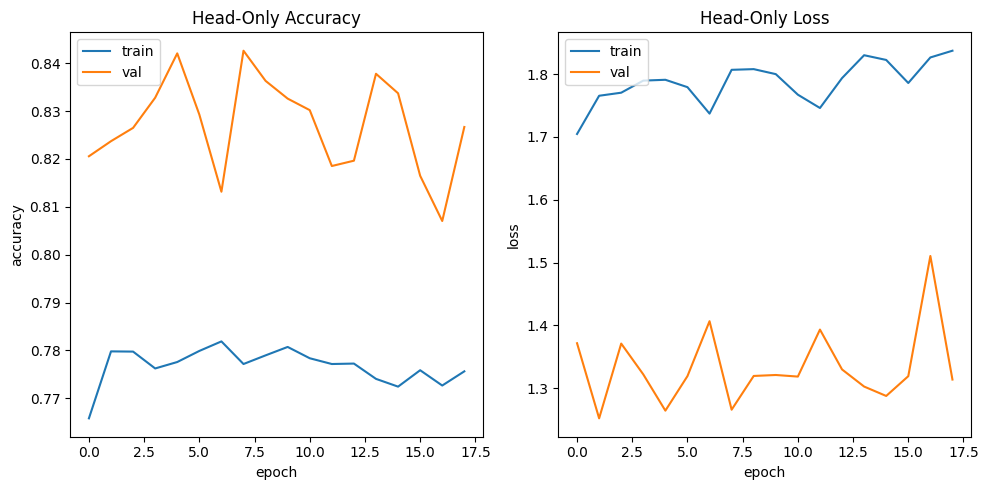


--- Fine-Tuning History ---


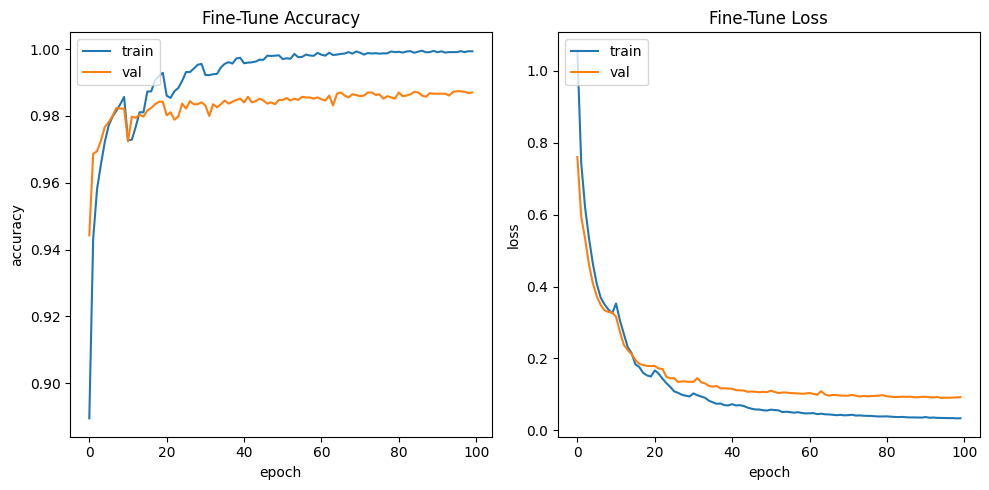

In [15]:
# Plot training history from CSV logs (works across Kaggle/session restarts)

def plot_from_log(log_path, title_prefix=''):
    """Plot training/validation accuracy and loss from a CSV log file."""
    df = pd.read_csv(log_path)

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.plot(df['categorical_accuracy'], label='train')
    plt.plot(df['val_categorical_accuracy'], label='val')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.title(f'{title_prefix} Accuracy' if title_prefix else 'Accuracy')
    plt.legend(loc='upper left')

    plt.subplot(1, 2, 2)
    plt.plot(df['loss'], label='train')
    plt.plot(df['val_loss'], label='val')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.title(f'{title_prefix} Loss' if title_prefix else 'Loss')
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

if os.path.exists(HEAD_LOG):
    print("--- Head-Only Training History ---")
    plot_from_log(HEAD_LOG, 'Head-Only')

if os.path.exists(FINETUNE_LOG):
    print("\n--- Fine-Tuning History ---")
    plot_from_log(FINETUNE_LOG, 'Fine-Tune')

## 7. Evaluation

Load the best checkpoint and evaluate on the held-out test set: overall
accuracy/F2-score plus a per-class precision/recall/F-score breakdown.

In [16]:
resnet152V2_model.load_weights(FINETUNE_CHECKPOINT)

class_indices = train_generator.class_indices
class_indices = dict((v, k) for k, v in class_indices.items())

test_generator_new = test_gen.flow_from_directory(
    directory=TEST_DIR,
    target_size=(128, 128),
    batch_size=1,
    class_mode=None,
    color_mode='rgb',
    shuffle=False,
    seed=69,
)

predictions = resnet152V2_model.predict(
    test_generator_new, steps=len(test_generator_new.filenames)
)
predicted_classes = np.argmax(np.rint(predictions), axis=1)
true_classes = test_generator_new.classes

prf, conf_mat = display_results(true_classes, predicted_classes, class_indices.values())
prf

Found 5400 images belonging to 10 classes.
5400/5400 ━━━━━━━━━━━━━━━━━━━━ 99s 17ms/step
Accuracy: 0.9868518518518519
Macro F1 Score: 0.9863530104099132
Global F2 Score: 0.9868518518518519


,Precision,Recall,F-Score,Support
AnnualCrop,0.975124,0.980000,0.977556,600.0
Forest,0.990083,0.998333,0.994191,600.0
HerbaceousVegetation,0.983193,0.975000,0.979079,600.0
Highway,0.984095,0.990000,0.987039,500.0
Industrial,0.995992,0.994000,0.994995,500.0
Pasture,0.979798,0.970000,0.974874,400.0
PermanentCrop,0.975952,0.974000,0.974975,500.0
Residential,0.996672,0.998333,0.997502,600.0
River,0.985972,0.984000,0.984985,500.0
SeaLake,0.998333,0.998333,0.998333,600.0


Confusion matrix for the per-class breakdown above:

In [17]:
conf_mat

,AnnualCrop,Forest,HerbaceousVegetation,Highway,Industrial,Pasture,PermanentCrop,Residential,River,SeaLake
AnnualCrop,588,0,0,0,0,6,4,0,1,1
Forest,1,599,0,0,0,0,0,0,0,0
HerbaceousVegetation,2,4,585,0,0,1,8,0,0,0
Highway,1,0,0,495,0,0,0,0,4,0
Industrial,0,0,0,1,497,0,0,1,1,0
Pasture,3,1,7,0,0,388,0,0,1,0
PermanentCrop,7,0,3,0,1,1,487,1,0,0
Residential,0,0,0,0,1,0,0,599,0,0
River,1,0,0,7,0,0,0,0,492,0
SeaLake,0,1,0,0,0,0,0,0,0,599


A random sample of test images with predicted vs. true labels (green = correct, red = incorrect):

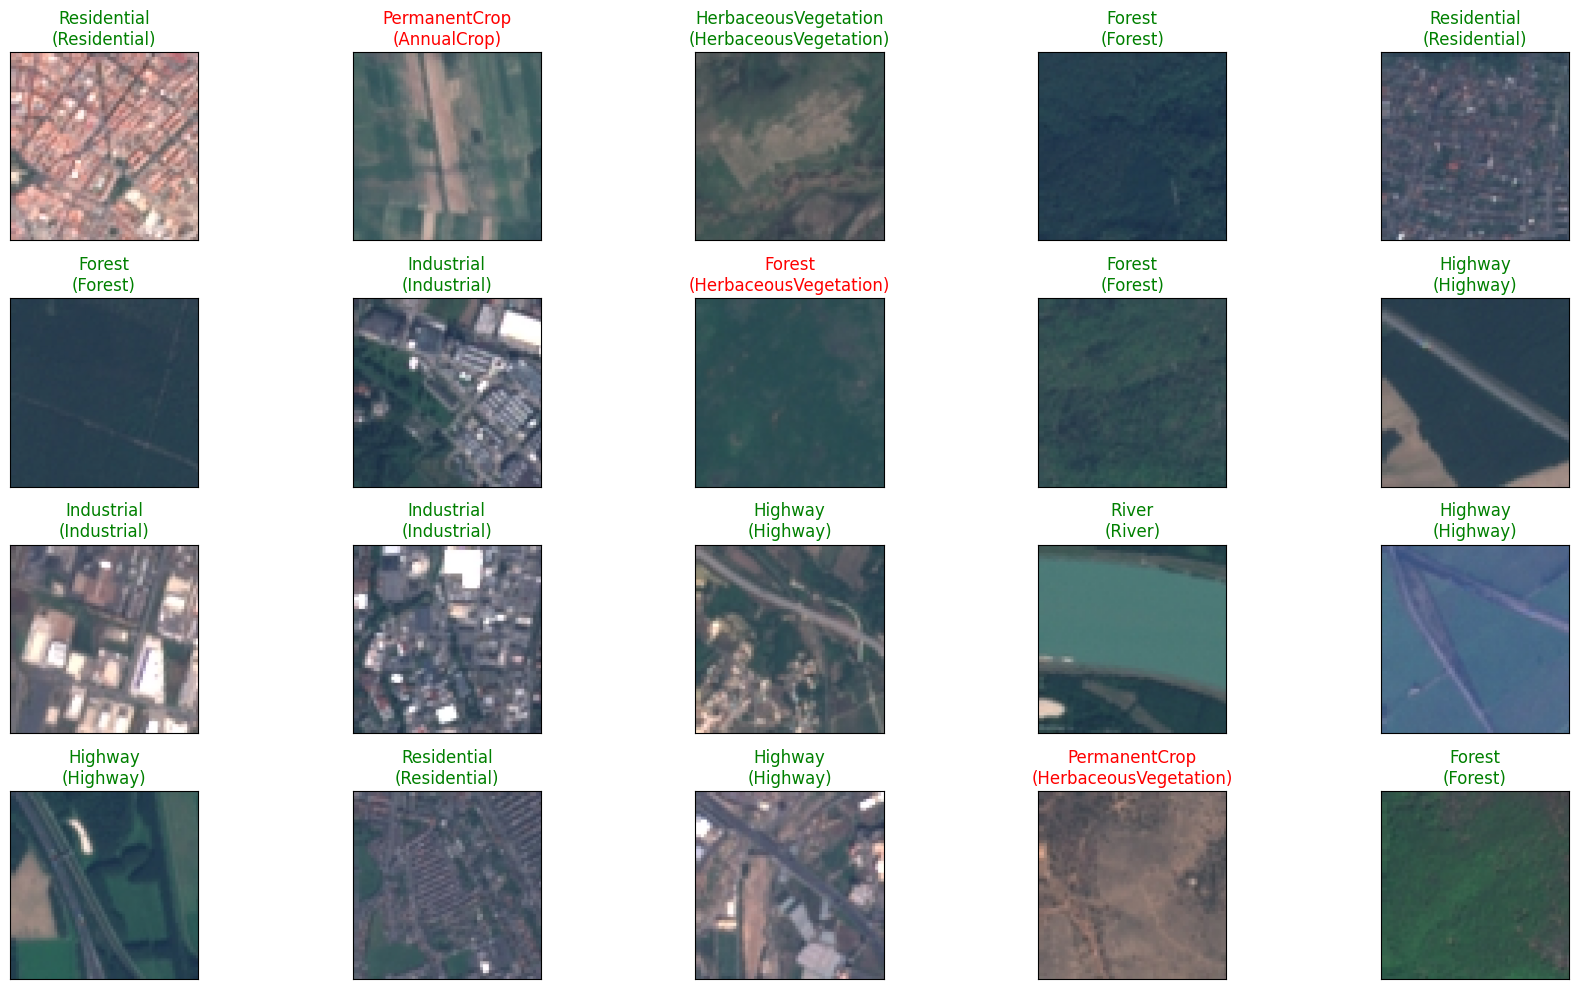

In [18]:
plot_predictions(true_classes, predictions, test_generator_new, class_indices)

## 8. Save the Model

Persist the fine-tuned model for later reuse or comparison against the other architectures.

In [19]:
resnet152V2_model.save(os.path.join(SAVE_DIR, 'ResNet152V2_eurosat.keras'))
np.save(os.path.join(SAVE_DIR, 'class_indices.npy'), train_generator.class_indices)

# Zip and download the results
import shutil
from google.colab import files

shutil.make_archive('EuroSAT_Training_Results', 'zip', SAVE_DIR)
files.download('EuroSAT_Training_Results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>